# Exploratory Data Analysis (EDA)

This notebook performs an exploratory data analysis on the final, pre-processed dataset (`final_ml_ready_dataset.csv`).

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_style('whitegrid')

## 2. Load Data

In [2]:
input_path = Path("../data/processed/final_ml_ready_dataset.csv")

try:
    df = pd.read_csv(input_path)
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: Dataset not found at '{input_path}'. Please run the full data pipeline first.")

Dataset loaded successfully. Shape: (2619, 202)


## 3. Basic Information

In [3]:
if 'df' in locals():
    print("--- Dataset Info ---")
    df.info()
    print("\n--- Null Value Check ---")
    print(df.isnull().sum().any())
    print("\n--- Descriptive Statistics (Numerical Features) ---")
    display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2619 entries, 0 to 2618
Columns: 202 entries, transaction_amount to is_fraud
dtypes: bool(88), float64(101), int64(13)
memory usage: 2.5 MB

--- Null Value Check ---
False

--- Descriptive Statistics (Numerical Features) ---


,transaction_amount,description_length,transaction_frequency,consistency_score,entity_has_payment_instruments,entity_has_gift_cards,entity_has_crypto,entity_has_subscriptions,entity_has_refunds,entity_has_P2P,...,tfidf_travel,tfidf_trip,tfidf_utility,tfidf_value,tfidf_visit,tfidf_wash,tfidf_weekend,tfidf_weekly,tfidf_work,is_fraud
count,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.0,2619.000000,...,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000
mean,140.017205,33.987400,14.169149,8.858343,0.037037,0.001527,0.008782,0.103093,0.0,0.006873,...,0.006373,0.026999,0.007232,0.004609,0.013849,0.008014,0.010115,0.025564,0.008386,0.076365
std,428.047567,11.193086,3.659916,2.263272,0.188889,0.039058,0.093318,0.304138,0.0,0.082633,...,0.064127,0.114573,0.069206,0.051469,0.095534,0.073284,0.078154,0.109627,0.070172,0.265632
min,1.760000,11.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,25.000000,11.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,32.730000,34.000000,14.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,87.560000,43.000000,17.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6231.290000,68.000000,24.000000,10.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,1.000000,1.000000,0.849678,0.712449,1.000000,0.687056,1.000000,1.000000,0.913734,1.000000


## 4. Target Variable Distribution

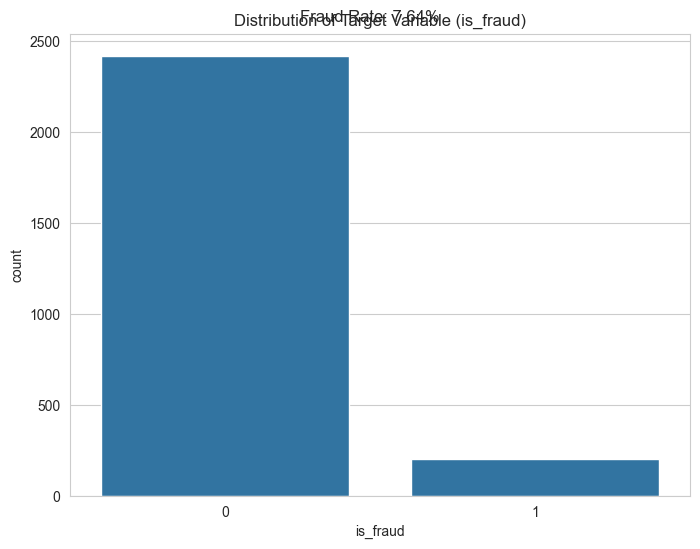

In [4]:
if 'df' in locals():
    plt.figure(figsize=(8, 6))
    sns.countplot(x='is_fraud', data=df)
    plt.title('Distribution of Target Variable (is_fraud)')
    fraud_rate = df['is_fraud'].value_counts(normalize=True).loc[1] * 100
    plt.suptitle(f'Fraud Rate: {fraud_rate:.2f}%', y=0.92)
    plt.show()

## 5. Numerical Feature Distributions

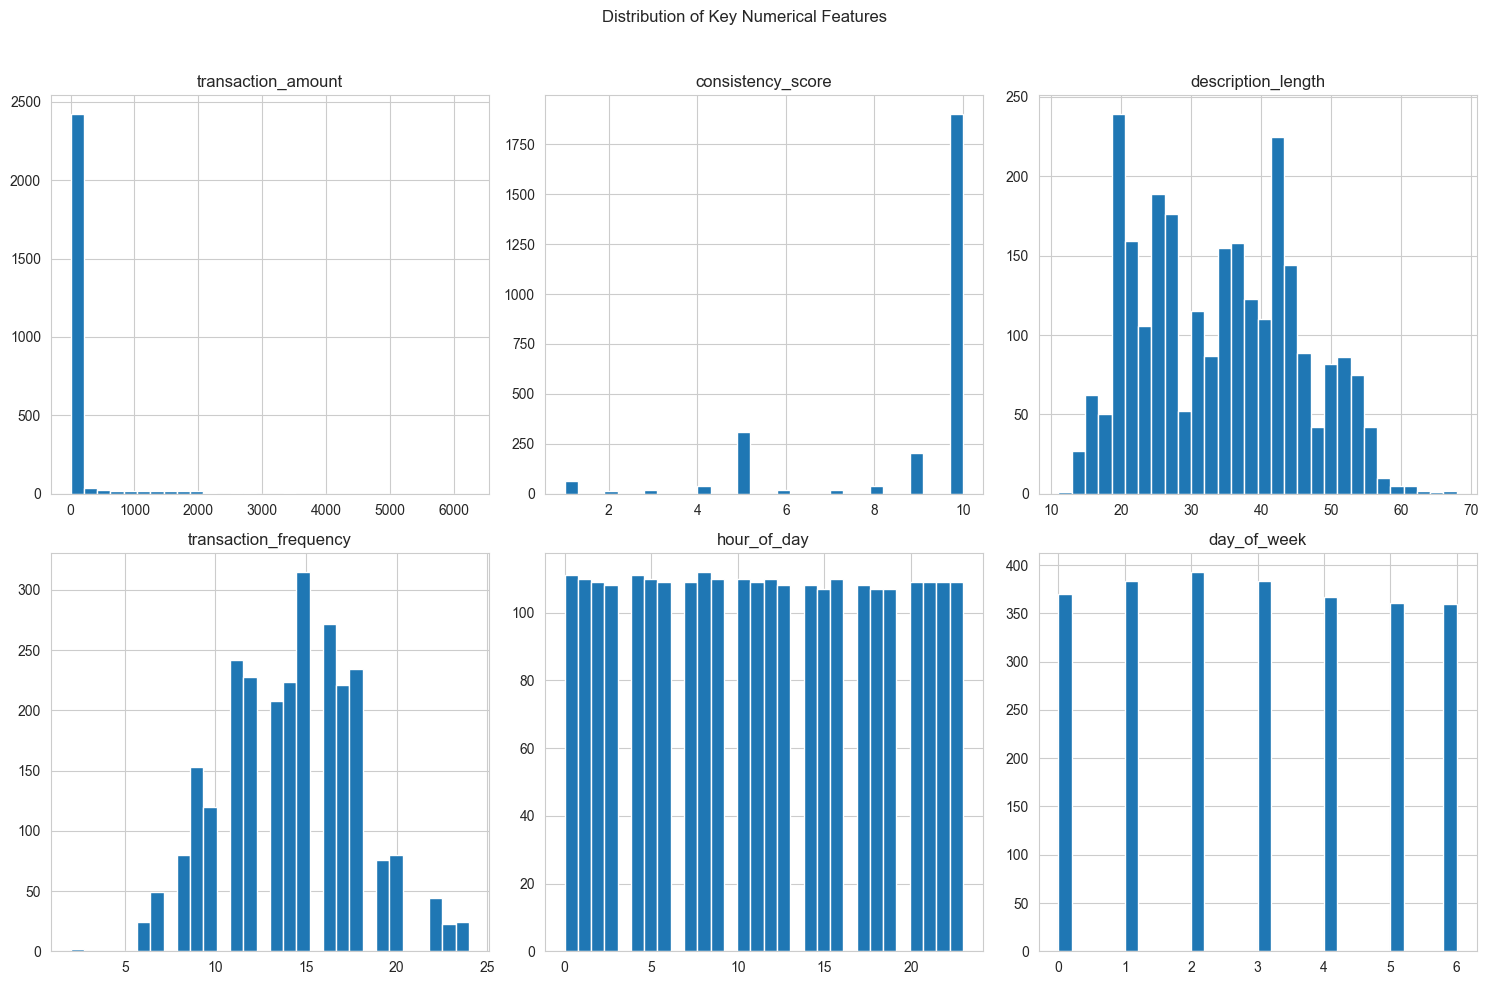

In [5]:
if 'df' in locals():
    numerical_cols = [
        'transaction_amount',
        'consistency_score',
        'description_length',
        'transaction_frequency',
        'hour_of_day',
        'day_of_week'
    ]
    
    df[numerical_cols].hist(bins=30, figsize=(15, 10), layout=(2, 3))
    plt.suptitle('Distribution of Key Numerical Features')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 6. Correlation Analysis

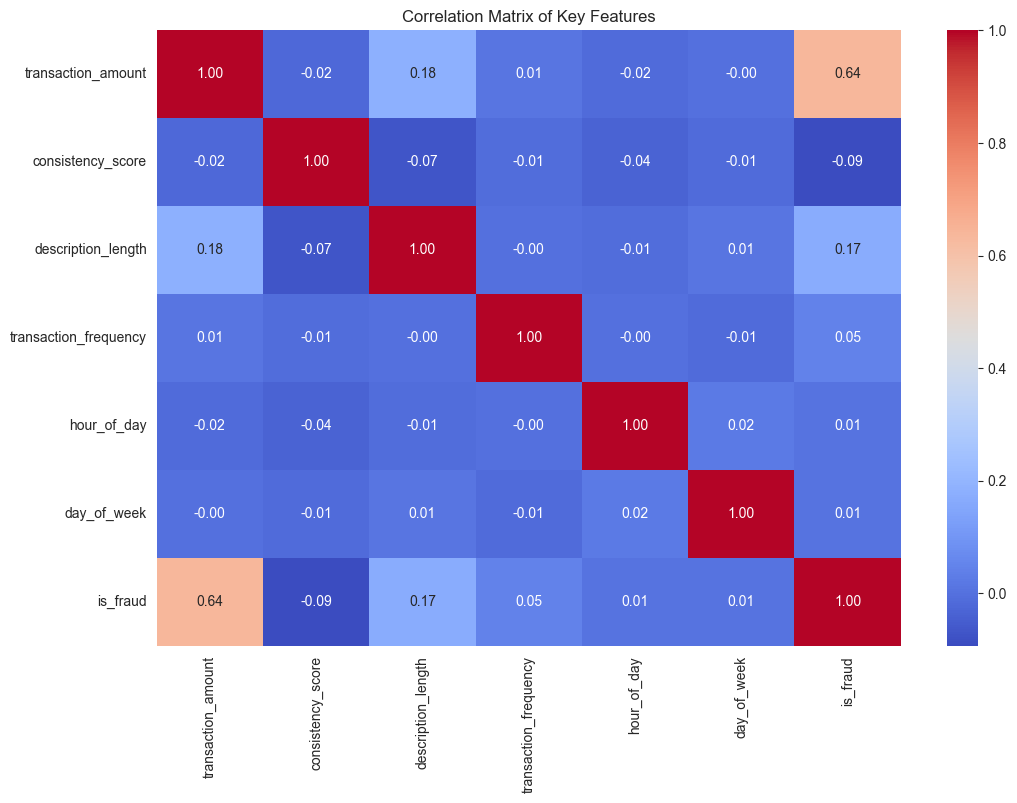

In [6]:
if 'df' in locals():
    # Select only the key numerical and target variables for a readable heatmap
    corr_df = df[numerical_cols + ['is_fraud']]
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Key Features')
    plt.show()